# **Machine Learning Project** - Medical Appointment No-Show Prediction

Project mentor: Johnny  <jpham19@jhu.edu>

Demarri Dosunmu <ddosunm1@jh.edu>, Shaun Ku <sku5@jh.edu>, Jay Modi <jmodi7@jh.edu>, Ronit Sohal <rsohal2@jh.edu>

https://github.com/demarrid/EN.601.475.01.SP26-final

# **Outline and Deliverables**

## **Uncompleted Deliverables**
1. **Dataset extension and cross-population generalization** <br> We were not able to complete this because we did not have access to comparable appointment no-show datasets from other regions or healthcare systems. Therefore, our analysis is limited to the Brazil dataset.

## **Completed Deliverables**

### **Must Accomplish**

1. **Data cleaning, feature engineering, and train/test split** <br>
In the ["Pre-Processing Data"](#scrollTo=D0RyhqcLfXRt&line=1&uniqifier=1) section <br>
Completed. We cleaned invalid values, engineered time, age, neighborhood, and medical-condition features, and used a stratified train-test split.

2. **Baseline models** <br>
In the ["Logistic Regression"](#scrollTo=KHjfdpdTeGQV) and ["Decision Tree"](#scrollTo=Zsf5VBideM0L) sections <br>
Completed. We implemented logistic regression and decision tree baselines.

3. **Metrics and feature importance** <br>
In the model evaluation parts under ["Methods"](#scrollTo=6akUfnxpJRM6) <br>
Completed. We reported accuracy, precision, recall, F1 score, confusion matrices, probability plots, and feature importance where applicable.

### **Expect to Accomplish**

1. **Model comparison** <br>
In the ["Results"](#scrollTo=QfMbKoBCJhsY) section <br>
Completed. We compared logistic regression, decision tree, random forest, CatBoost, and MLP.

2. **Class imbalance handling** <br>
In the ["Split Data"](#scrollTo=4jCJPAWNgaGT&line=1&uniqifier=1) section and model training sections under ["Methods"](#scrollTo=6akUfnxpJRM6) <br>
Completed. We used stratified splitting to preserve the original label distribution and tested class weighting in logistic regression, decision tree, random forest, and CatBoost. We did not implement resampling methods such as oversampling or undersampling.

3. **Error analysis** <br>
In the model evaluation sections under ["Methods"](#scrollTo=6akUfnxpJRM6) <br>
Completed. We analyzed model errors using confusion matrices and classification metrics. We also evaluated fairness across gender and age groups to identify where models performed unevenly.

### **Would Like to Accomplish**

1. **Hyperparameter tuning** <br>
In the ["Logistic Regression"](#scrollTo=KHjfdpdTeGQV), ["Decision Tree"](#scrollTo=Zsf5VBideM0L), ["Random Forest"](#scrollTo=5DTlbO4seP87), and ["CatBoost"](#scrollTo=BIVjX154eUEq) sections <br>
Completed. We used grid search for several models. The neural network used fixed training settings rather than full grid search.

2. **Threshold/probability analysis** <br>
Primarily in the ["Logistic Regression"](#scrollTo=KHjfdpdTeGQV) section <br>
Partially completed. We explored threshold adjustment using F1-threshold curves for logistic regression and probability distribution plots for some models, but did not perform formal probability calibration.

3. **Risk scoring or visualization tool** <br>
In the model evaluation sections under ["Methods"](#scrollTo=6akUfnxpJRM6) <br>
Partially completed. We created feature importance plots, confusion matrices, and probability visualizations, but did not build an interactive risk scoring tool.

## **Additional Work**
1. **Fairness evaluation** <br>
In the fairness analysis parts under ["Methods"](#scrollTo=6akUfnxpJRM6) <br>
We added fairness analysis across gender and age groups.

2. **CatBoost implementation** <br>
In the ["CatBoost"](#scrollTo=BIVjX154eUEq) section <br>
We added CatBoost as an additional tabular model.


# **Install Dependencies**

In [ ]:
# !pip install kagglehub pandas datasets
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import torch
from torch.utils.data import TensorDataset, DataLoader
from torch import nn

# **Preliminaries**

## **What problem were you trying to solve or understand?**

Medical appointment no-shows lead to significant inefficiencies and financial losses in healthcare systems, and existing interventions are often insufficient to address the problem. In this project, we use machine learning models on structured appointment data to predict no-shows and analyze which patient, health, and scheduling factors are most predictive of attendance. Accurate prediction of no-shows can help hospitals optimize scheduling, reduce wasted medical resources, improve clinic utilization, and allow healthcare providers to proactively intervene with high-risk patients through reminders or rescheduling systems.

The project also applies concepts including feature engineering, preprocessing, train-test splitting, handling class imbalance, hyperparameter tuning, and evaluation using metrics such as precision, recall, and F1 score. However, this problem is unique because human behavior is inherently difficult to predict, and many important factors affecting attendance, such as transportation issues, work schedules, motivation, or emergencies, are not captured in the dataset. As a result, the data is noisy and not linearly separable, making prediction more challenging for simpler models.

In addition, this problem has important ethical implications because the model may perform differently across demographic groups such as age or gender. Biased predictions could lead to unequal treatment or unfair allocation of healthcare resources, so fairness evaluation and careful interpretation are necessary to ensure the model is used responsibly.

## **Dataset(s)**

We used the Medical Appointment No Shows dataset from Kaggle
. The dataset contains medical appointment records from Brazil, including features such as age, gender, neighborhood, diseases, scholarship status, scheduled date, appointment date, and whether the patient attended the appointment. The data was collected from real healthcare appointment records and published publicly for machine learning research.

We chose this dataset because it represents a realistic healthcare prediction problem with important real-world applications, such as reducing wasted medical resources and improving scheduling efficiency.

The dataset contains approximately 110,000 appointment records with 14 features and one binary target label for appointment attendance.

In [ ]:
# Set the path to the file you'd like to load
file_path = "KaggleV2-May-2016.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "joniarroba/noshowappointments",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

# print("First 5 records:", df.head())

/tmp/ipykernel_2677/3758754486.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 2.40M/2.40M [00:00<00:00, 154MB/s]

Extracting zip of KaggleV2-May-2016.csv...


## **Pre-Processing Data**


We used both continuous and categorical features from the dataset, including age, gender, scholarship status, diseases, SMS reminders, and appointment scheduling information. We converted the scheduled day and appointment day into datetime format and extracted additional time-related features such as waiting days, appointment day of the week, and scheduled hour. We also added age-related features to indicate whether a patient is a child or elderly.

Since neighborhood was originally a categorical string feature, we encoded it using frequency encoding based on how often each neighborhood appears in the dataset. We also combined several medical conditions into a single feature representing the total number of conditions. The target label was encoded into binary form, where no-show is 1 and show is 0.

We removed features such as patient ID and appointment ID because they do not provide meaningful predictive information and are difficult to interpret. We also removed invalid records with negative waiting days or negative ages as part of our sanity checks.

### **Endode Data**


In [ ]:
## Convert to datetime
df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"])
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"])

## Convert to Unix timestamp (seconds since 1970)
df["Scheduled_ts"] = df["ScheduledDay"].astype("int64") // 10**9
df["Appointment_ts"] = df["AppointmentDay"].astype("int64") // 10**9

## Add more timestamp feature
df["waiting_days"] = (df["AppointmentDay"] - df["ScheduledDay"]).dt.days
df["appointment_dayofweek"] = df["AppointmentDay"].dt.dayofweek
df["scheduled_hour"] = df["ScheduledDay"].dt.hour

## Add more age related features
df["is_child"] = (df["Age"] < 18).astype(int)
df["is_elderly"] = (df["Age"] >= 60).astype(int)

## Sanity Checks
df = df[df["waiting_days"] >= 0]
df = df[df["Age"] >= 0]

## Geneder encoding
df["Gender"] = df["Gender"].map({"F": 0, "M": 1})

## For Neighbourhood - Can use one-hot encoding or use frequency
freq = df["Neighbourhood"].value_counts(normalize=True)
df["Neighbourhood_freq"] = df["Neighbourhood"].map(freq)

## Medical feature comination
df["num_conditions"] = (df["Hipertension"] + df["Diabetes"] + df["Alcoholism"] + df["Handcap"])

## Target encoding
df["No-show"] = df["No-show"].map({"Yes": 1, "No": 0})

## Drop unused columns
df = df.drop(columns=[
    "PatientId",
    "AppointmentID",
    "ScheduledDay",
    "AppointmentDay",
    "Neighbourhood"
])

### **Split data**


The dataset was moderately imbalanced, with more show-up cases than no-show cases, so we preserved the class distribution using stratified train-test splitting. Continuous features were standardized using StandardScaler before model training.

In [ ]:
## Split to training and testing data
X = df.drop("No-show", axis=1)
y = df["No-show"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Sample data for visualization
idx = np.random.RandomState(42).choice(len(X_train_scaled), 3000, replace=False)
X_sample = X_train_scaled[idx]
y_sample = y_train.iloc[idx]

print("Train label ratio:")
print(y_train.value_counts(normalize=True))

print("\nTest label ratio:")
print(y_test.value_counts(normalize=True))

Train label ratio:
No-show
0    0.714802
1    0.285198
Name: proportion, dtype: float64

Test label ratio:
No-show
0    0.714842
1    0.285158
Name: proportion, dtype: float64


### **Plot Data**


We used PCA and t-SNE visualizations on the training set to analyze the feature distribution and class separability, which suggested that the dataset is not linearly separable and may be challenging for simpler models.

#### **Label Distribution**

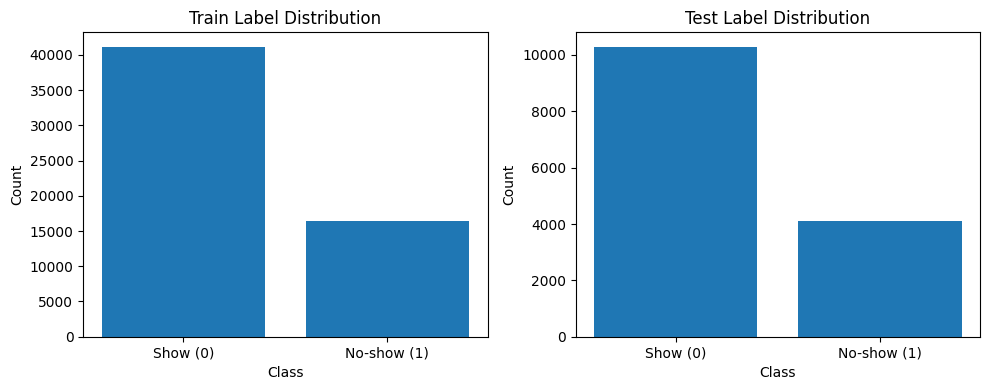

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(y_train, bins=[-0.5, 0.5, 1.5], rwidth=0.8)
axes[0].set_xticks([0, 1], ["Show (0)", "No-show (1)"])
axes[0].set_title("Train Label Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

axes[1].hist(y_test, bins=[-0.5, 0.5, 1.5], rwidth=0.8)
axes[1].set_xticks([0, 1], ["Show (0)", "No-show (1)"])
axes[1].set_title("Test Label Distribution")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

#### **PCA**

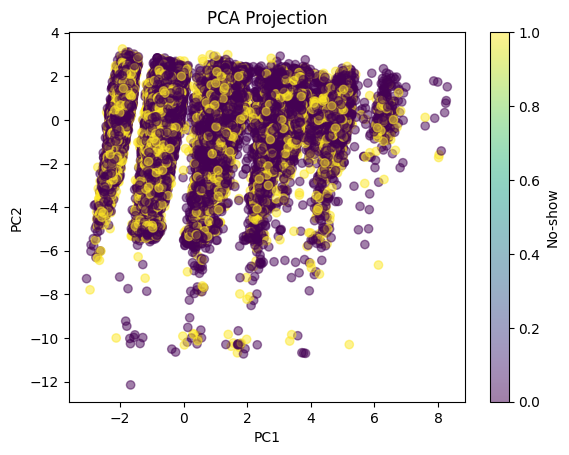

In [ ]:
## Plot the data using PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_train_scaled)
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.colorbar(label="No-show")
plt.show()

#### **t-SNE**

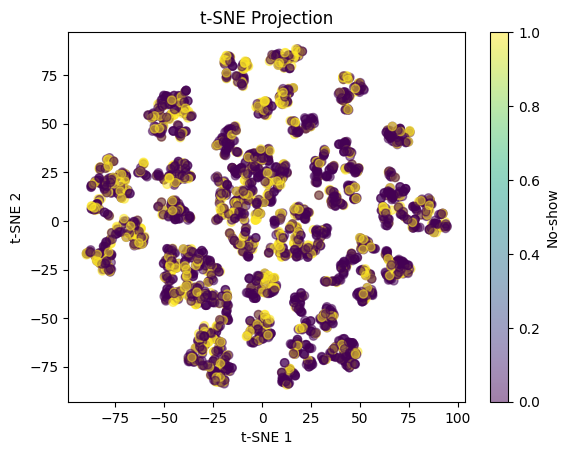

In [ ]:
X_tsne = TSNE(n_components=2, random_state=42, perplexity=10).fit_transform(X_sample)
plt.figure()
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_sample,
    alpha=0.5
)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Projection")
plt.colorbar(scatter, label="No-show")
plt.show()

# **Helper functions**

In [ ]:
def evaluate_fairness(
    X_test_raw,
    y_test,
    y_pred,
    y_prob=None,
    group_col="Gender",
    group_map=None
):
    # Build evaluation dataframe
    eval_df = X_test_raw.copy()
    eval_df["y_true"] = y_test.values
    eval_df["y_pred"] = y_pred

    if y_prob is not None:
        eval_df["y_prob"] = y_prob

    ## Optional mapping (e.g., 0/1 → Female/Male)
    if group_map is not None:
        eval_df[group_col + "_label"] = eval_df[group_col].map(group_map)
        group_col = group_col + "_label"

    rows = []

    for group_name, group_data in eval_df.groupby(group_col, observed=True):
        rows.append({
            "group": str(group_name),
            "count": len(group_data),
            "accuracy": accuracy_score(group_data["y_true"], group_data["y_pred"]),
            "precision": precision_score(group_data["y_true"], group_data["y_pred"], zero_division=0),
            "recall": recall_score(group_data["y_true"], group_data["y_pred"], zero_division=0),
            "f1": f1_score(group_data["y_true"], group_data["y_pred"], zero_division=0),
        })

    fairness_df = pd.DataFrame(rows)
    print(f"\nFairness evaluation by {group_col}:")
    print(fairness_df)

    return fairness_df

## Group data by ages for fairness check
X_test_age = X_test.copy()
X_test_age["Age_group"] = pd.cut(
    X_test_age["Age"],
    bins=[0, 18, 40, 65, 120],
    labels=["0-17", "18-39", "40-64", "65+"],
    right=False
)

# **Models and Evaluation**

## **Experimental Setup**

We evaluated our models using accuracy, precision, recall, and F1 score, with F1 score as the primary metric for model selection. Since the dataset is moderately imbalanced, F1 score is more suitable than accuracy because it balances both precision and recall. We also evaluated fairness by comparing model performance across demographic groups such as gender and age.

## **Baselines**

We used logistic regression and decision tree as our baseline models. Logistic regression is a reasonable baseline because it is a simple and interpretable linear model for binary classification. It helps us understand how well a basic linear decision boundary can perform on this task. Decision tree is also a reasonable baseline because it can capture some nonlinear relationships while still being relatively simple and interpretable. These two models give us a reference point for comparing more complex models such as random forest, CatBoost, and the neural network.

## **Methods**

We used five models: logistic regression, decision tree, random forest, CatBoost, and a simple neural network. Logistic regression served as our baseline because it is simple, interpretable, and suitable for binary classification. Decision tree, random forest, and CatBoost were chosen because they can capture nonlinear relationships in tabular data. The neural network was added as a more flexible model for comparison.

All models were trained on the training set and evaluated on the held-out test set. We used F1 score as the main evaluation metric because the dataset is imbalanced, so accuracy alone could be misleading. We also reported accuracy, precision, recall, confusion matrices, probability distributions, feature importance, and fairness results by gender and age group.

For logistic regression, we tuned regularization strength, penalty type, class weight, and classification threshold. For decision trees and random forests, we tuned maximum depth, minimum samples for splitting, minimum samples per leaf, class weight, and for random forest, the number of trees and maximum features. For CatBoost, we tuned depth, learning rate, iterations, and class weighting. For the neural network, we used a small fully connected model trained with binary cross-entropy loss and tuned basic training parameters such as learning rate, batch size, and epochs.

Logistic regression was the easiest to train and interpret, but it was limited because the data was not linearly separable. Tree-based models were also easy to implement and generally better at capturing nonlinear patterns. Random forest and CatBoost were more computationally expensive, while the neural network required the most manual training code and was more sensitive to hyperparameters.

Logistic Regression: regularization parameter; not sensitive
Tree-models: depth & feature bagging; increasing either categorically worsened loss greatly
CatBoost: sensitive to depth and class weighting, but not iterations or reasonable learning rates
Neural Network: insensitive to all hyperparams

### **Logistic Regression**

Best config:
{'C': 0.01, 'penalty': 'l1', 'class_weight': 'balanced', 'threshold': 0.44999999999999996, 'solver': 'liblinear'}
Accuracy:  0.4390
Precision: 0.3137
Recall:    0.8146
F1 Score:  0.4530


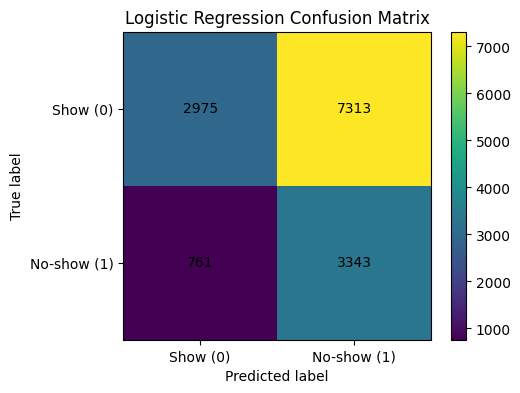

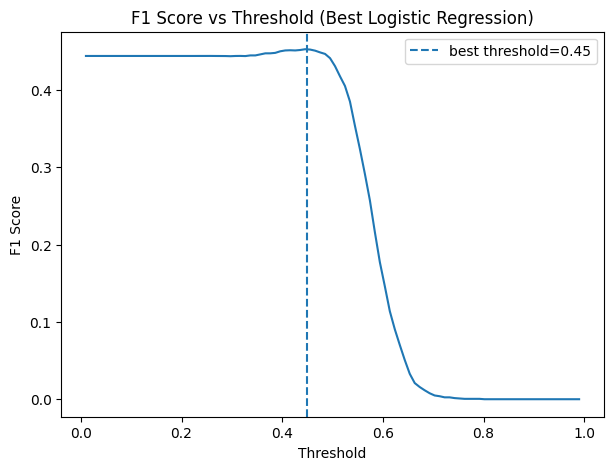

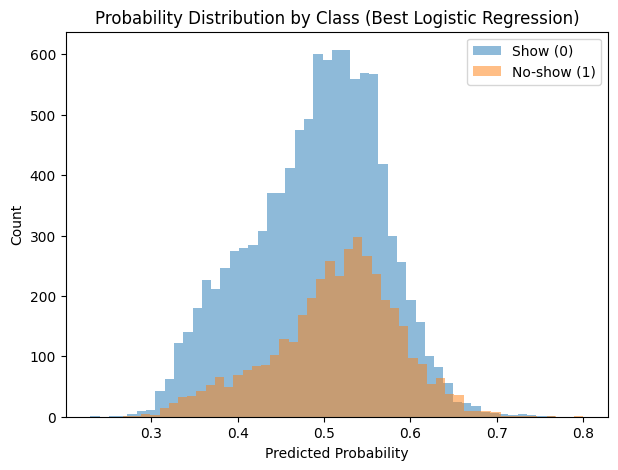


Fairness evaluation by Gender_label:
    group  count  accuracy  precision    recall        f1
0  Female   9628  0.438824   0.309595  0.799559  0.446357
1    Male   4764  0.439337   0.321734  0.844203  0.465907

Fairness evaluation by Age_group:
   group  count  accuracy  precision    recall        f1
0   0-17   3289  0.318638   0.315693  0.996139  0.479443
1  18-39   4094  0.347093   0.342398  0.990701  0.508911
2  40-64   4977  0.471971   0.278562  0.695513  0.397800
3    65+   2032  0.738189   0.256637  0.137441  0.179012


In [ ]:
## Logistic Regression

def grid_search_logistic_regression(
    X_train,
    X_test,
    y_train,
    y_test,
    C_list=(0.01, 0.1, 1, 10),
    penalties=("l1", "l2"),
    class_weights=(None, "balanced"),
    threshold_grid=None,
    max_iter=1000
):

    if threshold_grid is None:
        threshold_grid = np.linspace(0.2, 0.6, 9)

    best_f1 = -1
    best_config = None
    best_prob = None
    best_model = None

    ## Search over all parameter combinations
    for C in C_list:
        for penalty in penalties:
            for cw in class_weights:
                solver = "lbfgs" if penalty == "l2" else "liblinear"

                ## Initial model
                model = LogisticRegression(
                    C=C,
                    penalty=penalty,
                    max_iter=max_iter,
                    class_weight=cw,
                    solver=solver
                )

                ## Train
                model.fit(X_train, y_train)

                ## Predict
                y_prob = model.predict_proba(X_test)[:, 1]

                ## Check threshold vs f1_score
                for threshold in threshold_grid:
                    y_pred = (y_prob >= threshold).astype(int)
                    f1 = f1_score(y_test, y_pred)

                    ## Save best config
                    if f1 > best_f1:
                        best_f1 = f1
                        best_config = {
                            "C": C,
                            "penalty": penalty,
                            "class_weight": cw,
                            "threshold": float(threshold),
                            "solver": solver
                        }
                        best_prob = y_prob.copy()
                        best_model = model

    ## Report best config
    print("Best config:")
    print(best_config)

    ## Use the best threshold to get final predictions
    best_pred = (best_prob >= best_config["threshold"]).astype(int)

    ## Final metrics
    acc = accuracy_score(y_test, best_pred)
    prec = precision_score(y_test, best_pred, zero_division=0)
    rec = recall_score(y_test, best_pred, zero_division=0)

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {best_f1:.4f}")

    ## Plot confusion matrix
    cm = confusion_matrix(y_test, best_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Logistic Regression Confusion Matrix")
    plt.colorbar()
    plt.xticks([0, 1], ["Show (0)", "No-show (1)"])
    plt.yticks([0, 1], ["Show (0)", "No-show (1)"])
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.show()

    ## Compute F1 curve for the best model's probabilities
    thresholds = np.linspace(0.01, 0.99, 100)
    f1_scores = []

    for t in thresholds:
        curve_pred = (best_prob >= t).astype(int)
        f1_scores.append(f1_score(y_test, curve_pred))

    ## Plot F1 curve
    plt.figure(figsize=(7, 5))
    plt.plot(thresholds, f1_scores)
    plt.axvline(best_config["threshold"], linestyle="--", label=f'best threshold={best_config["threshold"]:.2f}')
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.title("F1 Score vs Threshold (Best Logistic Regression)")
    plt.legend()
    plt.show()

    ## Plot histogram for best model
    plt.figure(figsize=(7, 5))
    plt.hist(best_prob[y_test == 0], bins=50, alpha=0.5, label="Show (0)")
    plt.hist(best_prob[y_test == 1], bins=50, alpha=0.5, label="No-show (1)")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Count")
    plt.title("Probability Distribution by Class (Best Logistic Regression)")
    plt.legend()
    plt.show()

     ## Coefficients as feature importance
    feature_importance = best_model.coef_[0]

    return {
        "model": best_model,
        "best_config": best_config,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": best_f1,
        "feature_importance": feature_importance,
        "best_prob": best_prob,
        "best_pred": best_pred
    }

lr_results = grid_search_logistic_regression(
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

## Check fairness
lr_gender_fairness = evaluate_fairness(
    X_test,
    y_test,
    lr_results["best_pred"],
    lr_results["best_prob"],
    group_col="Gender",
    group_map={0: "Female", 1: "Male"}
)

lr_age_fairness = evaluate_fairness(
    X_test_age,
    y_test,
    lr_results["best_pred"],
    lr_results["best_prob"],
    group_col="Age_group"
)

### **Decision Tree**

Best Decision Tree F1: 0.4470
Best config:
{'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 1, 'class_weight': 'balanced'}
Accuracy:  0.4984
Precision: 0.3260
Recall:    0.7110
F1 Score:  0.4470


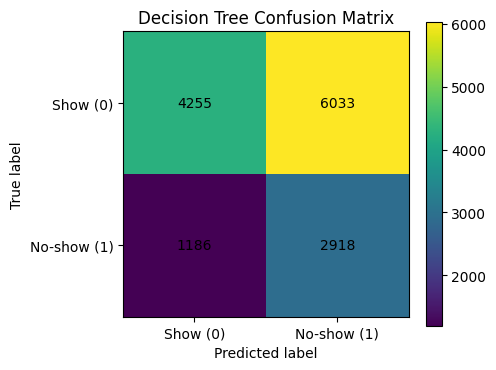

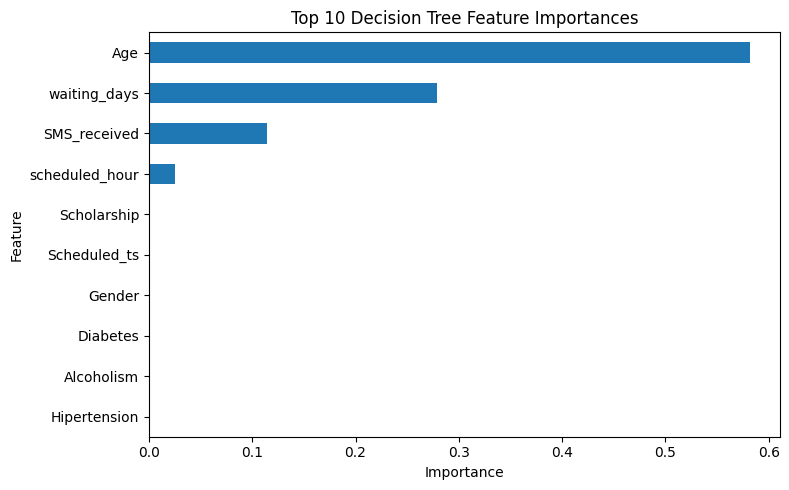

Classification Report:
              precision    recall  f1-score   support

           0     0.7820    0.4136    0.5410     10288
           1     0.3260    0.7110    0.4470      4104

    accuracy                         0.4984     14392
   macro avg     0.5540    0.5623    0.4940     14392
weighted avg     0.6520    0.4984    0.5142     14392


Fairness evaluation by Gender_label:
    group  count  accuracy  precision    recall        f1
0  Female   9628  0.499481   0.322488  0.698605  0.441275
1    Male   4764  0.496222   0.332787  0.735507  0.458239

Fairness evaluation by Age_group:
   group  count  accuracy  precision    recall        f1
0   0-17   3289  0.361812   0.322062  0.928571  0.478250
1  18-39   4094  0.377382   0.347226  0.935622  0.506486
2  40-64   4977  0.612015   0.307171  0.435897  0.360384
3    65+   2032  0.685039   0.244131  0.246445  0.245283


In [ ]:
## Decision Tree
def grid_search_decision_tree(
    X_train,
    X_test,
    y_train,
    y_test,
    max_depth_list=(3, 5, 10, 15, None),
    min_samples_split_list=(2, 10, 25),
    min_samples_leaf_list=(1, 5, 10),
    class_weights=(None, "balanced")
):
    best_f1 = -1
    best_model = None
    best_config = None
    best_prob = None
    best_pred = None

    for max_depth in max_depth_list:
        for min_samples_split in min_samples_split_list:
            for min_samples_leaf in min_samples_leaf_list:
                for cw in class_weights:
                    model = DecisionTreeClassifier(
                        max_depth=max_depth,
                        min_samples_split=min_samples_split,
                        min_samples_leaf=min_samples_leaf,
                        class_weight=cw,
                        random_state=42
                    )

                    model.fit(X_train, y_train)
                    y_pred = model.predict(X_test)
                    f1 = f1_score(y_test, y_pred)

                    if f1 > best_f1:
                        best_f1 = f1
                        best_model = model
                        best_pred = y_pred
                        best_prob = model.predict_proba(X_test)[:, 1]
                        best_config = {
                            "max_depth": max_depth,
                            "min_samples_split": min_samples_split,
                            "min_samples_leaf": min_samples_leaf,
                            "class_weight": cw
                        }

    print(f"Best Decision Tree F1: {best_f1:.4f}")
    print("Best config:")
    print(best_config)

    acc = accuracy_score(y_test, best_pred)
    prec = precision_score(y_test, best_pred, zero_division=0)
    rec = recall_score(y_test, best_pred, zero_division=0)

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {best_f1:.4f}")

    cm = confusion_matrix(y_test, best_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Decision Tree Confusion Matrix")
    plt.colorbar()
    plt.xticks([0, 1], ["Show (0)", "No-show (1)"])
    plt.yticks([0, 1], ["Show (0)", "No-show (1)"])
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.tight_layout()
    plt.show()

    feature_importance = pd.Series(best_model.feature_importances_, index=X_train.columns)
    feature_importance = feature_importance.sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    feature_importance.head(10).sort_values().plot(kind="barh")
    plt.title("Top 10 Decision Tree Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    print("Classification Report:")
    print(classification_report(y_test, best_pred, digits=4))

    return {
        "model": best_model,
        "best_config": best_config,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": best_f1,
        "feature_importance": feature_importance,
        "best_prob": best_prob,
        "best_pred": best_pred
    }


decision_tree_results = grid_search_decision_tree(
    X_train,
    X_test,
    y_train,
    y_test
)

## Check fairness
dt_gender_fairness = evaluate_fairness(
    X_test,
    y_test,
    decision_tree_results["best_pred"],
    decision_tree_results["best_prob"],
    group_col="Gender",
    group_map={0: "Female", 1: "Male"}
)

dt_age_fairness = evaluate_fairness(
    X_test_age,
    y_test,
    decision_tree_results["best_pred"],
    decision_tree_results["best_prob"],
    group_col="Age_group"
)

### **Random Forest**

Best Random Forest F1: 0.4384
Best config:
{'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced'}
Accuracy:  0.5955
Precision: 0.3629
Recall:    0.5536
F1 Score:  0.4384


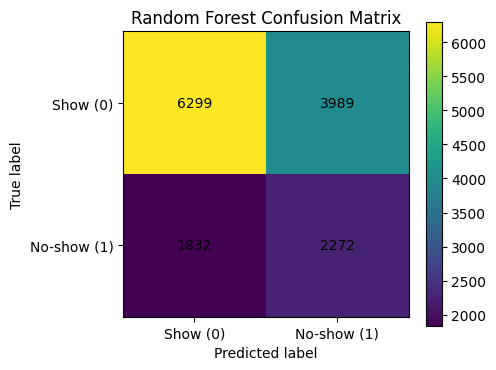

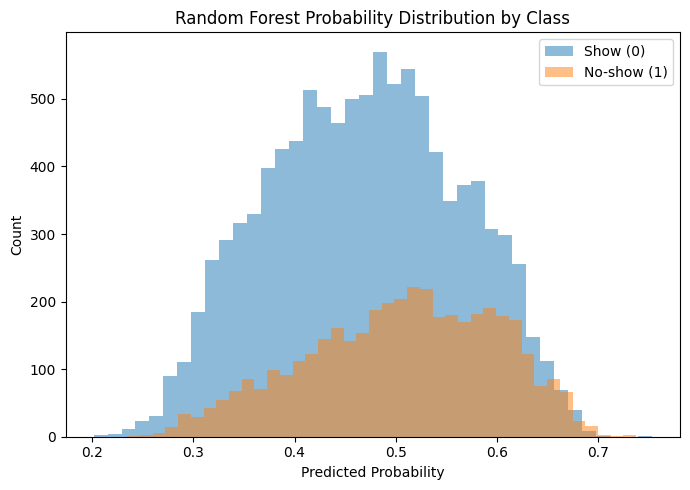

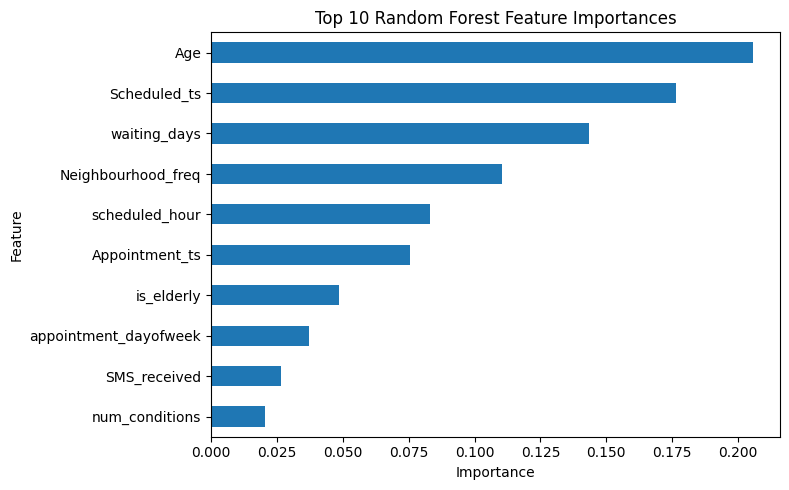

Classification Report:
              precision    recall  f1-score   support

           0     0.7747    0.6123    0.6840     10288
           1     0.3629    0.5536    0.4384      4104

    accuracy                         0.5955     14392
   macro avg     0.5688    0.5829    0.5612     14392
weighted avg     0.6573    0.5955    0.6139     14392


Fairness evaluation by Gender_label:
    group  count  accuracy  precision    recall        f1
0  Female   9628  0.586934   0.351856  0.546256  0.428017
1    Male   4764  0.612930   0.385827  0.568116  0.459555

Fairness evaluation by Age_group:
   group  count  accuracy  precision    recall        f1
0   0-17   3289  0.489510   0.349977  0.723938  0.471846
1  18-39   4094  0.466292   0.367997  0.784692  0.501028
2  40-64   4977  0.694193   0.371482  0.317308  0.342264
3    65+   2032  0.785925   0.408451  0.068720  0.117647


In [ ]:
## Random Forest
def grid_search_random_forest(
    X_train,
    X_test,
    y_train,
    y_test,
    n_estimators_list=(100, 200),
    max_depth_list=(5, 10, None),
    min_samples_split_list=(2, 10),
    min_samples_leaf_list=(1, 5),
    max_features_list=("sqrt", "log2"),
    class_weights=(None, "balanced")
):
    best_f1 = -1
    best_model = None
    best_config = None
    best_pred = None
    best_prob = None

    for n_estimators in n_estimators_list:
        for max_depth in max_depth_list:
            for min_samples_split in min_samples_split_list:
                for min_samples_leaf in min_samples_leaf_list:
                    for max_features in max_features_list:
                        for cw in class_weights:
                            model = RandomForestClassifier(
                                n_estimators=n_estimators,
                                max_depth=max_depth,
                                min_samples_split=min_samples_split,
                                min_samples_leaf=min_samples_leaf,
                                max_features=max_features,
                                class_weight=cw,
                                random_state=42,
                                n_jobs=-1
                            )

                            model.fit(X_train, y_train)
                            y_pred = model.predict(X_test)
                            y_prob = model.predict_proba(X_test)[:, 1]
                            f1 = f1_score(y_test, y_pred)

                            if f1 > best_f1:
                                best_f1 = f1
                                best_model = model
                                best_pred = y_pred
                                best_prob = y_prob
                                best_config = {
                                    "n_estimators": n_estimators,
                                    "max_depth": max_depth,
                                    "min_samples_split": min_samples_split,
                                    "min_samples_leaf": min_samples_leaf,
                                    "max_features": max_features,
                                    "class_weight": cw
                                }

    print(f"Best Random Forest F1: {best_f1:.4f}")
    print("Best config:")
    print(best_config)

    acc = accuracy_score(y_test, best_pred)
    prec = precision_score(y_test, best_pred, zero_division=0)
    rec = recall_score(y_test, best_pred, zero_division=0)

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {best_f1:.4f}")

    cm = confusion_matrix(y_test, best_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Random Forest Confusion Matrix")
    plt.colorbar()
    plt.xticks([0, 1], ["Show (0)", "No-show (1)"])
    plt.yticks([0, 1], ["Show (0)", "No-show (1)"])
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.hist(best_prob[y_test == 0], bins=40, alpha=0.5, label="Show (0)")
    plt.hist(best_prob[y_test == 1], bins=40, alpha=0.5, label="No-show (1)")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Count")
    plt.title("Random Forest Probability Distribution by Class")
    plt.legend()
    plt.tight_layout()
    plt.show()

    feature_importance = pd.Series(best_model.feature_importances_, index=X_train.columns)
    feature_importance = feature_importance.sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    feature_importance.head(10).sort_values().plot(kind="barh")
    plt.title("Top 10 Random Forest Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    print("Classification Report:")
    print(classification_report(y_test, best_pred, digits=4))

    return {
        "model": best_model,
        "best_config": best_config,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": best_f1,
        "feature_importance": feature_importance,
        "best_prob": best_prob,
        "best_pred": best_pred
    }


random_forest_results = grid_search_random_forest(
    X_train,
    X_test,
    y_train,
    y_test
)

## Check fairness
rf_gender_fairness = evaluate_fairness(
    X_test,
    y_test,
    random_forest_results["best_pred"],
    random_forest_results["best_prob"],
    group_col="Gender",
    group_map={0: "Female", 1: "Male"}
)

rf_age_fairness = evaluate_fairness(
    X_test_age,
    y_test,
    random_forest_results["best_pred"],
    random_forest_results["best_prob"],
    group_col="Age_group"
)

### **Gradient Boosting (CatBoost)**

starting
bestTest = 0.6177405172
bestIteration = 1
0:	loss: 0.6177405	best: 0.6177405 (0)	total: 13.8s	remaining: 3m 26s
bestTest = 0.6178934139
bestIteration = 1
1:	loss: 0.6178934	best: 0.6178934 (1)	total: 27.5s	remaining: 3m 12s
bestTest = 0.6177405172
bestIteration = 1
2:	loss: 0.6177405	best: 0.6178934 (1)	total: 55s	remaining: 3m 58s
bestTest = 0.6178934139
bestIteration = 1
3:	loss: 0.6178934	best: 0.6178934 (1)	total: 1m 41s	remaining: 5m 3s
bestTest = 0.6030545945
bestIteration = 2
4:	loss: 0.6030546	best: 0.6178934 (1)	total: 2m 7s	remaining: 4m 41s
bestTest = 0.603346963
bestIteration = 2
5:	loss: 0.6033470	best: 0.6178934 (1)	total: 2m 31s	remaining: 4m 13s
bestTest = 0.6030545945
bestIteration = 2
6:	loss: 0.6030546	best: 0.6178934 (1)	total: 3m 22s	remaining: 4m 20s
bestTest = 0.603346963
bestIteration = 2
7:	loss: 0.6033470	best: 0.6178934 (1)	total: 4m 6s	remaining: 4m 6s
Estimating final quality...
Training on fold [0/3]
bestTest = 0.5911649719
bestIteration = 57
Trai

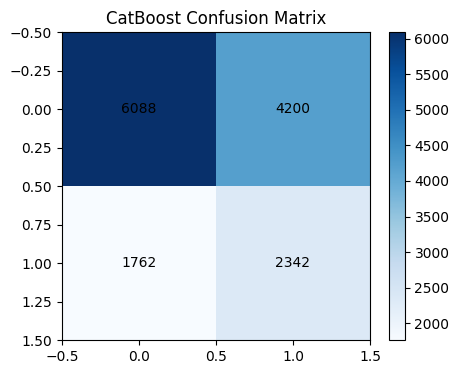

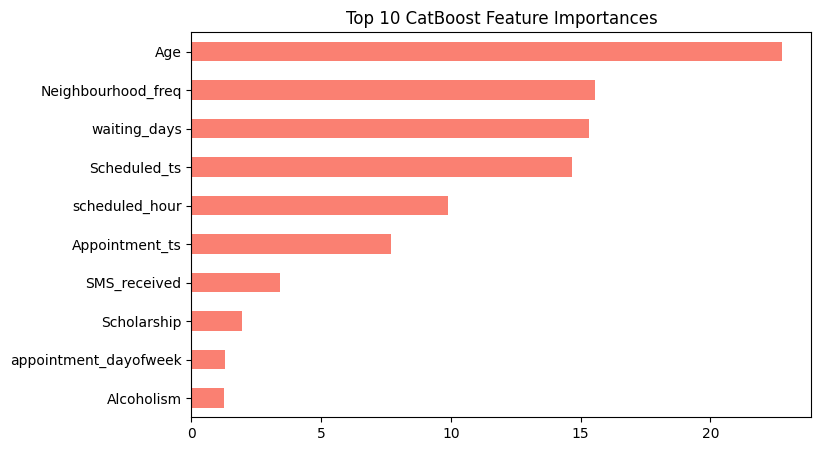


Fairness evaluation by Gender_label:
    group  count  accuracy  precision    recall        f1
0  Female   9628  0.578417   0.348742  0.564978  0.431274
1    Male   4764  0.600546   0.377172  0.581884  0.457680

Fairness evaluation by Age_group:
   group  count  accuracy  precision    recall        f1
0   0-17   3289  0.496503   0.351816  0.710425  0.470588
1  18-39   4094  0.464827   0.365730  0.772532  0.496438
2  40-64   4977  0.671087   0.352540  0.372596  0.362291
3    65+   2032  0.764764   0.342697  0.144550  0.203333


In [ ]:
## Gradient Boosting (CatBoost)

from catboost import CatBoostClassifier, Pool

def train_catboost_model(X_train, X_test, y_train, y_test, cat_features):

    train_pool = Pool(X_train, y_train, cat_features=cat_features)
    test_pool = Pool(X_test, y_test, cat_features=cat_features)

    model = CatBoostClassifier(
        loss_function='Logloss',
        eval_metric='F1',
        task_type='GPU',
        devices='0',
        random_seed=42,
        verbose=False
    )

    grid = {
        'depth': [4, 6],
        'learning_rate': [0.03, 0.1],
        'iterations': [500, 1000],
        'auto_class_weights': [None, 'Balanced']
    }

    print("starting")
    grid_search_result = model.grid_search(grid, train_pool, plot=False)

    # Final predictions
    best_pred = model.predict(X_test)
    best_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    f1 = f1_score(y_test, best_pred)
    acc = accuracy_score(y_test, best_pred)
    prec = precision_score(y_test, best_pred)
    rec = recall_score(y_test, best_pred)

    print(f"Best CatBoost F1: {f1:.4f}")
    print(f"Best Params: {grid_search_result['params']}")

    # Confusion Matrix Visualization
    cm = confusion_matrix(y_test, best_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap='Blues')
    plt.title("CatBoost Confusion Matrix")
    plt.colorbar()
    # Adding text to the CM
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.show()

    # Feature Importance
    feat_imp = model.get_feature_importance(train_pool, type='FeatureImportance')
    feature_importance = pd.Series(feat_imp, index=X_train.columns).sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    feature_importance.head(10).sort_values().plot(kind="barh", color='salmon')
    plt.title("Top 10 CatBoost Feature Importances")
    plt.show()

    return {
        "model": model,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "best_pred": best_pred,
        "best_prob": best_prob
    }

cat_cols = ['Gender', 'appointment_dayofweek', 'is_child', 'is_elderly', 'SMS_received']

catboost_results = train_catboost_model(X_train, X_test, y_train, y_test, cat_features=cat_cols)

# Fairness check for Gender
cb_gender_fairness = evaluate_fairness(
    X_test, # Use the raw X_test (before scaling)
    y_test,
    catboost_results["best_pred"],
    catboost_results["best_prob"],
    group_col="Gender",
    group_map={0: "Female", 1: "Male"}
)

# F4rness check for Age Groups
X_test_with_age = X_test.copy()
X_test_with_age["Age_group"] = pd.cut(
    X_test_with_age["Age"],
    bins=[0, 18, 40, 65, 120],
    labels=["0-17", "18-39", "40-64", "65+"],
    right=False
)

cb_age_fairness = evaluate_fairness(
    X_test_with_age,
    y_test,
    catboost_results["best_pred"],
    catboost_results["best_prob"],
    group_col="Age_group"
)

### **NN**

In [ ]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

threshold = 0.44
print(f"Using device: {device}")

class NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(15, 12, bias=True),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(12, 12, bias=True),
            nn.ReLU(),
            nn.Linear(12, 1, bias=True),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

def train_loop(dataloader, model, loss_fn, optimizer):
    batch_size = dataloader.batch_size
    size = len(dataloader.dataset)
    model.train()
    batch = 0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        pred = model(X)              # shape (batch,1)
        loss = loss_fn(pred, y)

        # Backpropr
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()  # zero the gradient
        batch += 1
        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"Loss: {loss:>7f} [{current:>5d}/{size:>5d}]")

def test_loop(dataloader, model, loss_fn):
    model.eval()
    #eval for batch normalziing and dropout
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            probs = torch.sigmoid(pred)
            pred_labels = (probs > threshold).float()
            correct += (pred_labels == y).float().sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test error: \n \tAccuracy:{(100*correct):>0.1f}%\n\tAverage loss: {test_loss:>8f} \n")


def train_nn():
    learning_rate = 1e-3
    epochs = 24
    batch_size = 128
    pos_weight = 2.5

    model = NN().to(device)
    print(model)
    X_train_model = X_train.drop(columns=["Scheduled_ts", "Appointment_ts"], errors="ignore").copy()
    X_test_model = X_test.drop(columns=["Scheduled_ts", "Appointment_ts"], errors="ignore").copy()
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_model)
    X_test_scaled = scaler.transform(X_test_model)

    X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
    X_test_t  = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)  # (N,1)
    y_test_t  = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)   # (N,1)
    train_ds = TensorDataset(X_train_t, y_train_t)
    test_ds = TensorDataset(X_test_t, y_test_t)
    train_dataloader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_dataloader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=device))
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for t in range(epochs):
        print(f"Epoch {t+1}\n-----------------------")
        train_loop(train_dataloader, model, loss_fn, optimizer)
        test_loop(test_dataloader, model, loss_fn)

    return model, scaler

def evaluate_fairness_nn(model, scaler):
    X_test_model = X_test.drop(columns=["Scheduled_ts", "Appointment_ts"], errors="ignore").copy()
    model.eval()
    X_test_scaled = scaler.transform(X_test_model)
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
    with torch.no_grad():
        logits = model(X_test_t)
        probs = torch.sigmoid(logits).cpu().numpy().ravel()
        preds = (probs > threshold).astype(int)

        print(probs.min(), probs.max())
        print(preds.mean())
        overall_precision = precision_score(y_test.values, preds, zero_division=0)
        overall_recall = recall_score(y_test.values, preds, zero_division=0)
        overall_f1 = f1_score(y_test.values, preds, zero_division=0)

        print(
            "Overall metrics:\n"
            f"\tprecision: {overall_precision:.4f}\n"
            f"\trecall: {overall_recall:.4f}\n"
            f"\tf1: {overall_f1:.4f}"
        )

        evaluate_fairness(
              X_test,
              y_test,
              preds,
              probs,
              group_col="Gender",
              group_map={0: "Female", 1: "Male"}
            )

        evaluate_fairness(
              X_test_age,
              y_test,
              preds,
              probs,
              group_col="Age_group"
            )

nn_model, nn_scaler = train_nn()
print("Completed!")
evaluate_fairness_nn(nn_model, nn_scaler)

Using device: cuda
NN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=15, out_features=12, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=12, out_features=12, bias=True)
    (4): ReLU()
    (5): Linear(in_features=12, out_features=1, bias=True)
  )
)
Epoch 1
-----------------------
Loss: 0.919346 [12928/57567]
Loss: 0.967563 [25728/57567]
Loss: 0.945891 [38528/57567]
Loss: 1.005511 [51328/57567]
Test error: 
 	Accuracy:42.1%
	Average loss: 0.976214 

Epoch 2
-----------------------
Loss: 1.069591 [12928/57567]
Loss: 0.840940 [25728/57567]
Loss: 0.954775 [38528/57567]
Loss: 1.072561 [51328/57567]
Test error: 
 	Accuracy:45.1%
	Average loss: 0.972461 

Epoch 3
-----------------------
Loss: 1.019566 [12928/57567]
Loss: 0.957881 [25728/57567]
Loss: 0.945411 [38528/57567]
Loss: 0.927093 [51328/57567]
Test error: 
 	Accuracy:47.1%
	Average loss: 0.971193 

Epoch 4
--------------------

## **Results**

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|
| Logistic Regression | 0.4390 | 0.3137 | 👑**0.8146** | 👑**0.4530** |
| Decision Tree | 0.4984 | 0.3260 | 0.7110 | 0.4470 |
| Random Forest | 👑**0.5955** | 👑**0.3629** | 0.5536 | 0.4384 |
| CatBoost | 0.5850 | 0.3566 | 0.5707 | 0.4400 |
| Neural Network | 0.4970 | 0.3251 | 0.7451 | 0.4527 |

Overall, logistic regression and the neural network achieved the highest F1 scores, both around 0.453, while random forest achieved the highest accuracy. Logistic regression had the highest recall, meaning it captured the most no-show cases, but it also produced many false positives. Random forest and CatBoost were more conservative: they had higher accuracy and precision, but lower recall for the no-show class.

One surprising result was that the more complex models did not clearly outperform the simpler baselines. We expected random forest, CatBoost, or the neural network to perform better because they can model nonlinear patterns. However, the improvement was limited, which suggests that the available features do not strongly separate show and no-show cases.

The models appear to underfit rather than overfit. Their F1 scores remained relatively low, and the probability distributions for show and no-show patients overlapped heavily. To address this, we used feature engineering, class weighting, threshold tuning, and hyperparameter search across several models.

These results suggest that the dataset is noisy and behavior-driven. Important factors such as transportation, appointment type, prior attendance history, work schedule, and patient motivation are not included. On richer datasets with more contextual information, these models may perform better, but fairness and generalization could also change across different healthcare systems or patient populations.  

# **Discussion**

## What you've learned

It's very clear that complicated real-world data and situations like these are the reason there is so much hype behind AI, as the ability to model any function is infinitely generalizable into the world. Even so, the fact that there simply isn't enough of a correlation or causational influence between the variables available and what we want to study, the neural network in our case simply could not achieve predictions better than random chance on the dataset overall (provided it knew the ratio of positive/negative).

What we found surprising is how imporant age groups were in our models' ability to be accurate. The general trend was that entropy increased with age, so models were able to accurately predict old-age no-shows but not young no-shows.

The most helpful feedback during the presentation involved questions regarding our fairness metric, as the gaps in accuracy between different groups were helpful but overall less important than values like F1 or recall, specifically. Turning our attention to these helped us understand the critical error in our implementation of the neural network.

With two more weeks to work on this project, we might look at class imbalance control strategies, as well as try to study the literature on no-shows closely to determine what a priori elements we could include in our models which might actually improve their predictive power given the size of the dataset.